In [1]:
!pip install osmnx networkx matplotlib numpy pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.7 MB/s eta 0:00:00


ETAPA 1 - Construção do Grafo
Região: Canguaretama, Rio Grande do Norte, Brazil
Tipo do grafo: MultiDiGraph
Número de nós (interseções): 856
Número de arestas (vias): 2288
O grafo é direcionado? True


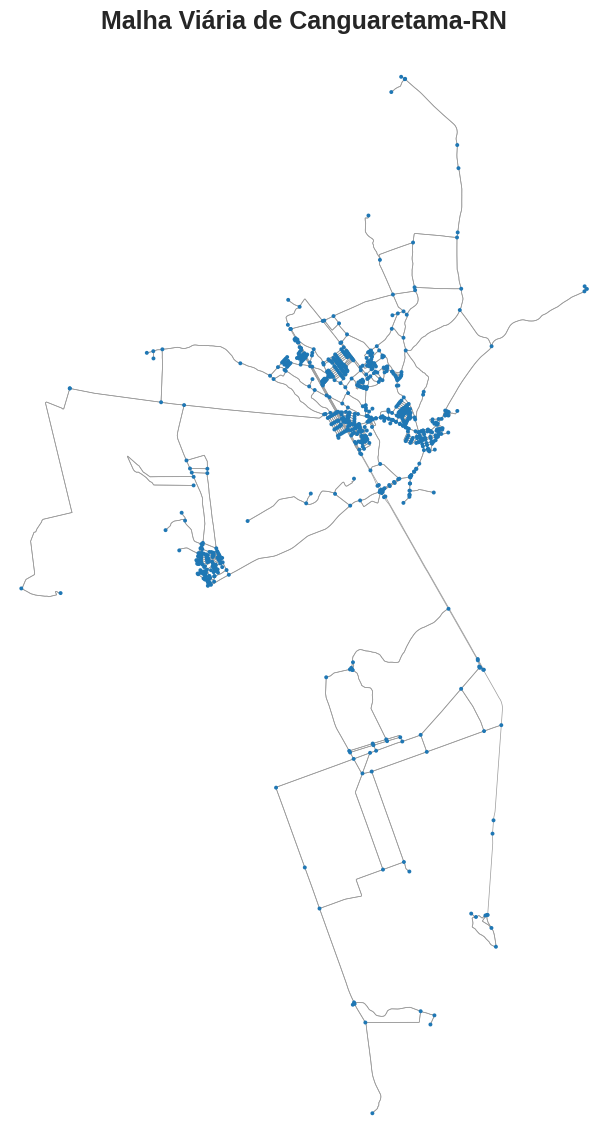


Grafo não-direcionado (OSMnx): 856 nós, 1219 arestas
Grafo simples (NetworkX):      856 nós, 1215 arestas

ETAPA 2 - Análise Estrutural

--- 2.1 Grau dos Nós ---
Grau mínimo: 1
Grau máximo: 4
Grau médio: 2.84
Mediana: 3.00
Desvio padrão: 0.75


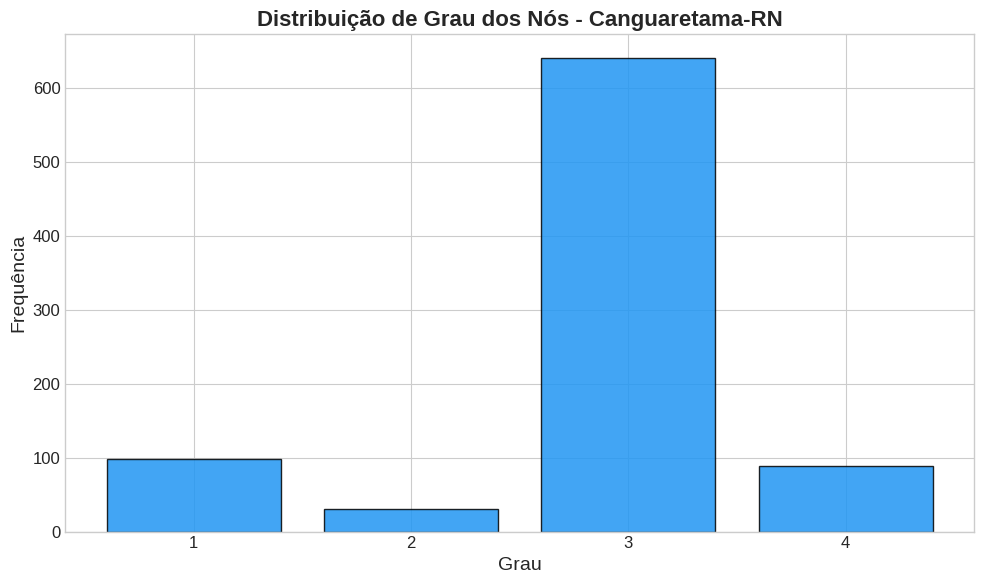


--- 2.2 Hubs (Top 10 por Grau) ---
         Node_ID  Grau
Rank                  
1      616958468     4
2      616958473     4
3      616958480     4
4     2311960516     4
5     2311960517     4
6     2311960518     4
7     2311960526     4
8     2311960529     4
9     2311960563     4
10    2311960566     4


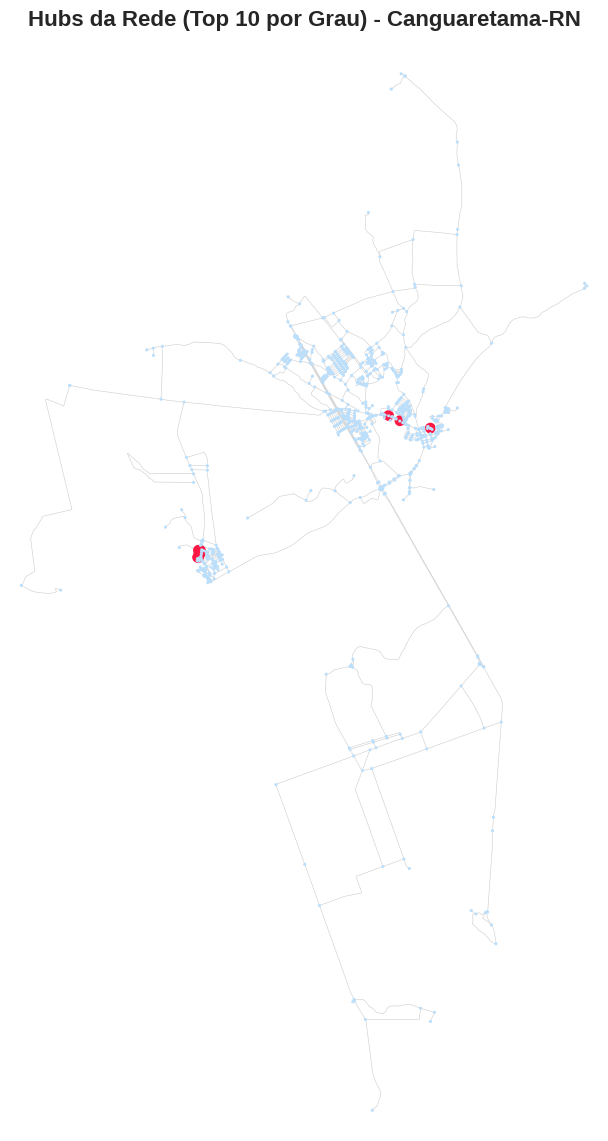


--- 2.3 Betweenness Centrality ---
Calculando betweenness centrality...
         Node_ID  Betweenness
Rank                         
1     4381522284     0.282185
2     4381522595     0.249040
3     7720310850     0.246313
4     6423437489     0.210378
5     7496558700     0.191825
6     7491912324     0.191621
7     4381522283     0.185087
8     4381522260     0.182023
9      352744810     0.181705
10    4381522259     0.174251


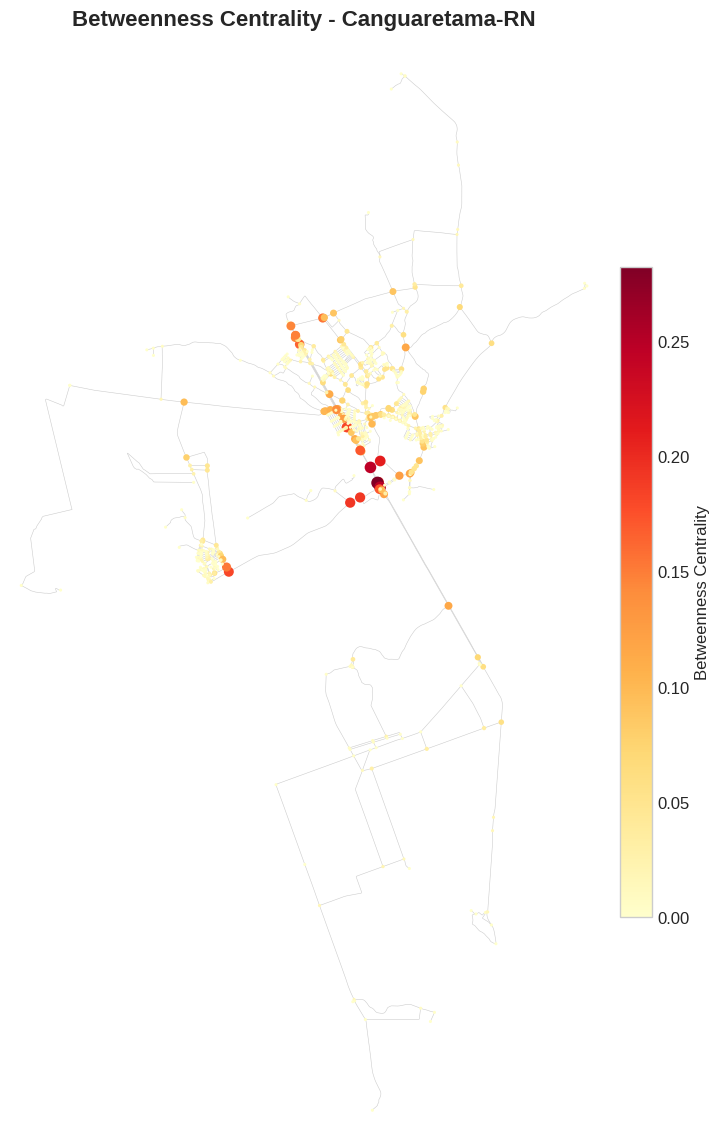


--- 2.4 Closeness Centrality ---
Calculando closeness centrality...
         Node_ID  Closeness
Rank                       
1      638996957   0.081382
2     7720310850   0.081058
3     4381522258   0.080744
4     7720310866   0.080026
5     4381522284   0.079579
6     4381522260   0.079468
7     4381522283   0.079225
8     6404114780   0.079123
9     4381522257   0.078737
10    6398909701   0.078700


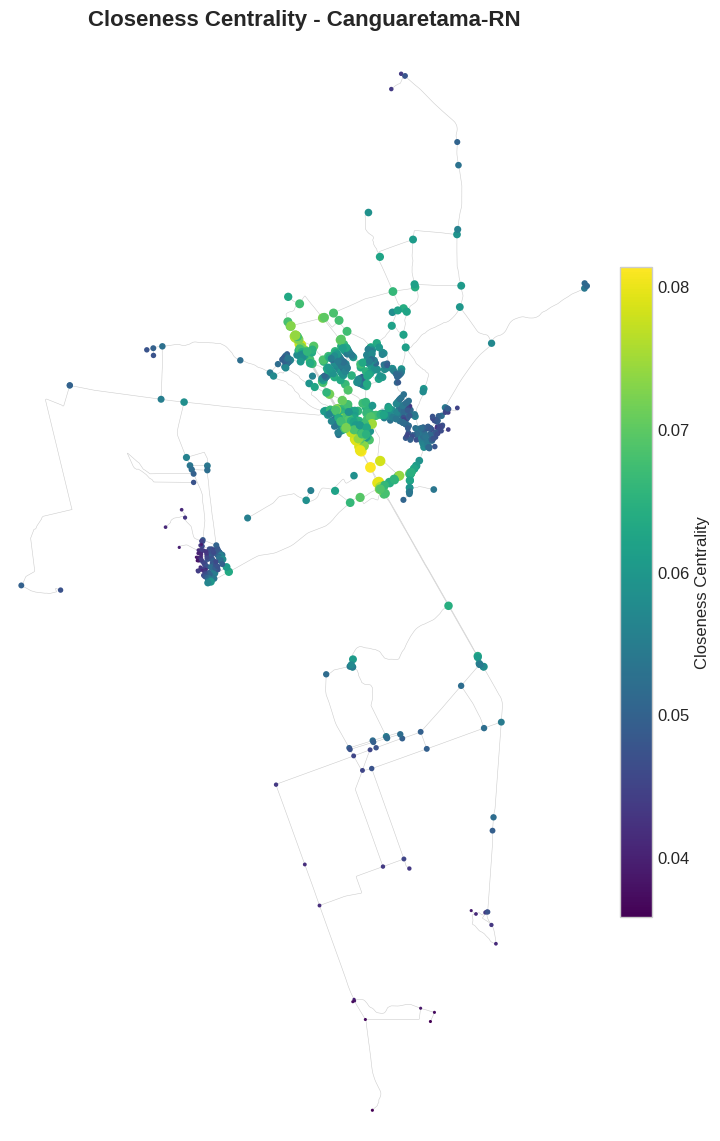


--- 2.5 Core Number e K-Core ---


NetworkXNotImplemented: Input graph has self loops which is not permitted; Consider using G.remove_edges_from(nx.selfloop_edges(G)).

In [4]:
#!/usr/bin/env python3
"""
Análise Estrutural da Rede Viária de Canguaretama-RN
Trabalho Prático - Estrutura de Dados II (DCA3702)
Autor: José Alex Araújo de Santana

Foco: Hubs e Core Decomposition
Ferramentas: OSMnx, NetworkX, Matplotlib, Gephi
"""

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

# ================================================================
# ETAPA 1 - CONSTRUÇÃO DO GRAFO COM OSMnx
# ================================================================
print('=' * 60)
print('ETAPA 1 - Construção do Grafo')
print('=' * 60)

place = 'Canguaretama, Rio Grande do Norte, Brazil'
G = ox.graph_from_place(place, network_type='drive')

print(f'Região: {place}')
print(f'Tipo do grafo: {type(G).__name__}')
print(f'Número de nós (interseções): {G.number_of_nodes()}')
print(f'Número de arestas (vias): {G.number_of_edges()}')
print(f'O grafo é direcionado? {G.is_directed()}')

# Visualização inicial (usa G original — MultiDiGraph do OSMnx)
fig, ax = ox.plot_graph(
    G, node_size=8, node_color='#1f77b4',
    edge_color='#999999', edge_linewidth=0.5,
    bgcolor='white', figsize=(14, 14),
    show=False, close=False
)
ax.set_title('Malha Viária de Canguaretama-RN', fontsize=18, fontweight='bold', pad=20)
plt.savefig('images/01_grafo_inicial.png', dpi=150, bbox_inches='tight')
plt.show()

# Conversão para grafo não-direcionado
# Justificativa: Métricas como k-core e centralidades
# requerem grafos não-direcionados para análise simétrica.
#
# DOIS grafos são mantidos:
#   G_undirected_ox  → MultiGraph OSMnx, usado em ox.plot_graph() e ox.save_graphml()
#   G_undirected     → Graph simples NetworkX, usado em nx.* (core_number, centralidades, etc.)
G_undirected_ox = ox.convert.to_undirected(G)          # MultiGraph — para plotagem e exportação
G_undirected = nx.Graph(G_undirected_ox)               # Graph simples — para cálculos NetworkX

print(f'\nGrafo não-direcionado (OSMnx): {G_undirected_ox.number_of_nodes()} nós, {G_undirected_ox.number_of_edges()} arestas')
print(f'Grafo simples (NetworkX):      {G_undirected.number_of_nodes()} nós, {G_undirected.number_of_edges()} arestas')

# ================================================================
# ETAPA 2 - ANÁLISE ESTRUTURAL COM NetworkX
# ================================================================
print('\n' + '=' * 60)
print('ETAPA 2 - Análise Estrutural')
print('=' * 60)

# --- 2.1 Grau dos Nós ---
print('\n--- 2.1 Grau dos Nós ---')
degree_dict = dict(G_undirected.degree())
degrees = list(degree_dict.values())

print(f'Grau mínimo: {min(degrees)}')
print(f'Grau máximo: {max(degrees)}')
print(f'Grau médio: {np.mean(degrees):.2f}')
print(f'Mediana: {np.median(degrees):.2f}')
print(f'Desvio padrão: {np.std(degrees):.2f}')

# Histograma
fig, ax = plt.subplots(figsize=(10, 6))
degree_counts = Counter(degrees)
graus = sorted(degree_counts.keys())
freqs = [degree_counts[g] for g in graus]
ax.bar(graus, freqs, color='#2196F3', edgecolor='black', alpha=0.85)
ax.set_xlabel('Grau', fontsize=14)
ax.set_ylabel('Frequência', fontsize=14)
ax.set_title('Distribuição de Grau dos Nós - Canguaretama-RN', fontsize=16, fontweight='bold')
ax.set_xticks(graus)
plt.tight_layout()
plt.savefig('images/02_distribuicao_grau.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2.2 Identificação dos Hubs ---
print('\n--- 2.2 Hubs (Top 10 por Grau) ---')
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
df_hubs = pd.DataFrame(top_degree, columns=['Node_ID', 'Grau'])
df_hubs.index = range(1, 11)
df_hubs.index.name = 'Rank'
print(df_hubs.to_string())

hub_nodes = [n for n, _ in top_degree]
node_colors = ['#FF1744' if n in hub_nodes else '#BBDEFB' for n in G_undirected_ox.nodes()]
node_sizes  = [60 if n in hub_nodes else 5 for n in G_undirected_ox.nodes()]

fig, ax = ox.plot_graph(
    G_undirected_ox, node_color=node_colors, node_size=node_sizes,   # ← ox usa G_undirected_ox
    edge_color='#CCCCCC', edge_linewidth=0.4,
    bgcolor='white', figsize=(14, 14), show=False, close=False
)
ax.set_title('Hubs da Rede (Top 10 por Grau) - Canguaretama-RN', fontsize=16, fontweight='bold', pad=20)
plt.savefig('images/03_hubs_grau.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2.3 Betweenness Centrality ---
print('\n--- 2.3 Betweenness Centrality ---')
print('Calculando betweenness centrality...')
betweenness = nx.betweenness_centrality(G_undirected, normalized=True)  # ← nx usa G_undirected
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

df_bet = pd.DataFrame(top_betweenness, columns=['Node_ID', 'Betweenness'])
df_bet.index = range(1, 11)
df_bet.index.name = 'Rank'
print(df_bet.to_string())

bet_values = [betweenness[n] for n in G_undirected_ox.nodes()]
vmin, vmax = min(bet_values), max(bet_values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd
node_colors_bet = [cmap(norm(v)) for v in bet_values]
node_sizes_bet  = [max(5, v / (vmax + 1e-10) * 80) for v in bet_values]

fig, ax = ox.plot_graph(
    G_undirected_ox, node_color=node_colors_bet, node_size=node_sizes_bet,
    edge_color='#CCCCCC', edge_linewidth=0.4,
    bgcolor='white', figsize=(14, 14), show=False, close=False
)
ax.set_title('Betweenness Centrality - Canguaretama-RN', fontsize=16, fontweight='bold', pad=20)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, label='Betweenness Centrality')
plt.savefig('images/04_betweenness.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2.4 Closeness Centrality ---
print('\n--- 2.4 Closeness Centrality ---')
print('Calculando closeness centrality...')
closeness = nx.closeness_centrality(G_undirected)
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]

df_close = pd.DataFrame(top_closeness, columns=['Node_ID', 'Closeness'])
df_close.index = range(1, 11)
df_close.index.name = 'Rank'
print(df_close.to_string())

close_values = [closeness[n] for n in G_undirected_ox.nodes()]
vmin_c, vmax_c = min(close_values), max(close_values)
norm_c = plt.Normalize(vmin=vmin_c, vmax=vmax_c)
cmap_c = plt.cm.viridis
node_colors_close = [cmap_c(norm_c(v)) for v in close_values]
node_sizes_close  = [max(5, (v - vmin_c) / (vmax_c - vmin_c + 1e-10) * 60) for v in close_values]

fig, ax = ox.plot_graph(
    G_undirected_ox, node_color=node_colors_close, node_size=node_sizes_close,
    edge_color='#CCCCCC', edge_linewidth=0.4,
    bgcolor='white', figsize=(14, 14), show=False, close=False
)
ax.set_title('Closeness Centrality - Canguaretama-RN', fontsize=16, fontweight='bold', pad=20)
sm_c = plt.cm.ScalarMappable(cmap=cmap_c, norm=norm_c)
sm_c.set_array([])
plt.colorbar(sm_c, ax=ax, fraction=0.03, pad=0.02, label='Closeness Centrality')
plt.savefig('images/05_closeness.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2.5 Core Number e K-Core ---
print('\n--- 2.5 Core Number e K-Core ---')
core_number = nx.core_number(G_undirected)   # ← requer Graph simples; G_undirected é correto
max_core = max(core_number.values())
main_core_nodes = [n for n, c in core_number.items() if c == max_core]

print(f'Maior core number: {max_core}')
print(f'Nós no núcleo principal (k={max_core}): {len(main_core_nodes)}')

core_counts = Counter(core_number.values())
print('\nDistribuição dos Core Numbers:')
for k in sorted(core_counts.keys()):
    print(f'  k={k}: {core_counts[k]} nós')

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(10, 6))
cores_sorted  = sorted(core_counts.keys())
counts_sorted = [core_counts[k] for k in cores_sorted]
bars = ax.bar(cores_sorted, counts_sorted, color='#7B1FA2', edgecolor='black', alpha=0.85)
ax.set_xlabel('Core Number (k)', fontsize=14)
ax.set_ylabel('Número de Nós', fontsize=14)
ax.set_title('Distribuição dos Core Numbers - Canguaretama-RN', fontsize=16, fontweight='bold')
ax.set_xticks(cores_sorted)
for bar, count in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/06_core_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Mapa por core number
core_values = [core_number[n] for n in G_undirected_ox.nodes()]
norm_k = plt.Normalize(vmin=min(core_values), vmax=max(core_values))
cmap_k = plt.cm.plasma
node_colors_core = [cmap_k(norm_k(v)) for v in core_values]
node_sizes_core  = [max(5, v / max_core * 50) for v in core_values]

fig, ax = ox.plot_graph(
    G_undirected_ox, node_color=node_colors_core, node_size=node_sizes_core,
    edge_color='#CCCCCC', edge_linewidth=0.4,
    bgcolor='white', figsize=(14, 14), show=False, close=False
)
ax.set_title(f'Core Number dos Nós (max k={max_core}) - Canguaretama-RN',
             fontsize=16, fontweight='bold', pad=20)
sm_k = plt.cm.ScalarMappable(cmap=cmap_k, norm=norm_k)
sm_k.set_array([])
plt.colorbar(sm_k, ax=ax, fraction=0.03, pad=0.02, label='Core Number')
plt.savefig('images/07_kcore_mapa.png', dpi=150, bbox_inches='tight')
plt.show()

# K-core subgraph destacado
k_core_subgraph = nx.k_core(G_undirected, k=max_core)
kcore_set = set(k_core_subgraph.nodes())

print(f'\nSubgrafo do {max_core}-core: {k_core_subgraph.number_of_nodes()} nós, {k_core_subgraph.number_of_edges()} arestas')

nc_kcore = ['#FF1744' if n in kcore_set else '#E0E0E0' for n in G_undirected_ox.nodes()]
ns_kcore = [40 if n in kcore_set else 3 for n in G_undirected_ox.nodes()]

fig, ax = ox.plot_graph(
    G_undirected_ox, node_color=nc_kcore, node_size=ns_kcore,
    edge_color='#CCCCCC', edge_linewidth=0.3,
    bgcolor='white', figsize=(14, 14), show=False, close=False
)
ax.set_title(f'Nós do {max_core}-Core Destacados (vermelho) - Canguaretama-RN',
             fontsize=16, fontweight='bold', pad=20)
plt.savefig('images/08_kcore_destacado.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2.6 Análise Comparativa ---
print('\n--- 2.6 Análise Comparativa ---')
nodes_list = list(G_undirected.nodes())

# Tabela comparativa
comparison_data = []
for rank in range(10):
    row = {
        'Rank': rank + 1,
        'Hub (Grau)':  f'{top_degree[rank][0]} (g={top_degree[rank][1]})',
        'Betweenness': f'{top_betweenness[rank][0]} (b={top_betweenness[rank][1]:.4f})',
        'Closeness':   f'{top_closeness[rank][0]} (c={top_closeness[rank][1]:.4f})'
    }
    comparison_data.append(row)

df_comp = pd.DataFrame(comparison_data).set_index('Rank')
print('Tabela Comparativa: Top 10 por Métrica')
print(df_comp.to_string())

# Overlap
hub_set = set([n for n, _ in top_degree])
bet_set = set([n for n, _ in top_betweenness])
overlap = hub_set.intersection(bet_set)
print(f'\nOverlap Top 10 Hubs x Top 10 Betweenness: {len(overlap)} nós em comum')

hubs_in_kcore = hub_set.intersection(kcore_set)
print(f'Hubs no K-Core máximo (k={max_core}): {len(hubs_in_kcore)} de 10')

# Scatter plots
deg_vals   = [degree_dict[n] for n in nodes_list]
bet_vals   = [betweenness[n] for n in nodes_list]
close_vals = [closeness[n]   for n in nodes_list]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(deg_vals, bet_vals,   alpha=0.5, c='#1565C0', edgecolor='black', s=30, linewidth=0.3)
axes[0].set_xlabel('Grau', fontsize=13)
axes[0].set_ylabel('Betweenness Centrality', fontsize=13)
axes[0].set_title('Grau vs Betweenness', fontsize=14, fontweight='bold')

axes[1].scatter(deg_vals, close_vals, alpha=0.5, c='#2E7D32', edgecolor='black', s=30, linewidth=0.3)
axes[1].set_xlabel('Grau', fontsize=13)
axes[1].set_ylabel('Closeness Centrality', fontsize=13)
axes[1].set_title('Grau vs Closeness', fontsize=14, fontweight='bold')

plt.suptitle('Correlação entre Métricas - Canguaretama-RN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/09_correlacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

# Nós-ponte (alto betweenness, baixo grau)
median_degree = np.median(degrees)
pontes = [(n, degree_dict[n], betweenness[n]) for n in nodes_list
          if betweenness[n] > np.percentile(list(betweenness.values()), 90)
          and degree_dict[n] <= median_degree]
pontes_sorted = sorted(pontes, key=lambda x: x[2], reverse=True)[:10]

print('\nNós-Ponte (alto betweenness, baixo grau):')
if pontes_sorted:
    df_pontes = pd.DataFrame(pontes_sorted, columns=['Node_ID', 'Grau', 'Betweenness'])
    df_pontes.index = range(1, len(df_pontes) + 1)
    print(df_pontes.to_string())
else:
    print('Nenhum nó-ponte identificado.')

# Top 10% por grau
threshold_10pct = np.percentile(degrees, 90)
top_10pct_nodes = [n for n in nodes_list if degree_dict[n] >= threshold_10pct]
print(f'\nTop 10% por Grau: limiar={threshold_10pct}, total={len(top_10pct_nodes)} nós')

# ================================================================
# ETAPA 3 - EXPORTAÇÃO PARA GEPHI
# ================================================================
print('\n' + '=' * 60)
print('ETAPA 3 - Exportação para Gephi')
print('=' * 60)

# Grava os atributos calculados no grafo OSMnx (G_undirected_ox) para exportação correta
nx.set_node_attributes(G_undirected_ox, degree_dict,  'degree')
nx.set_node_attributes(G_undirected_ox, betweenness,  'betweenness')
nx.set_node_attributes(G_undirected_ox, closeness,    'closeness')
nx.set_node_attributes(G_undirected_ox, core_number,  'core_number')

output_path = 'data/rede_canguaretama.graphml'
ox.save_graphml(G_undirected_ox, output_path)   # ← ox.save_graphml exige MultiGraph do OSMnx

print(f'Grafo exportado: {output_path}')
print('Atributos incluídos: x, y, degree, betweenness, closeness, core_number')

# ================================================================
# RESUMO FINAL
# ================================================================
print('\n' + '=' * 60)
print('RESUMO FINAL - Canguaretama-RN')
print('=' * 60)
print(f'Nós: {G_undirected.number_of_nodes()}')
print(f'Arestas: {G_undirected.number_of_edges()}')
print(f'Grau: min={min(degrees)} max={max(degrees)} média={np.mean(degrees):.2f}')
print(f'Betweenness máx: {max(betweenness.values()):.4f} (nó {top_betweenness[0][0]})')
print(f'Closeness máx:   {max(closeness.values()):.4f} (nó {top_closeness[0][0]})')
print(f'K-Core máximo: {max_core} ({len(main_core_nodes)} nós)')
print(f'Overlap Hubs x Betweenness: {len(overlap)}/10')
print(f'Hubs no K-Core máx: {len(hubs_in_kcore)}/10')
print(f'\nImagens salvas em: images/')
print(f'GraphML salvo em:  {output_path}')
print('\n✅ Análise concluída com sucesso!')